CAUSAL ANALYTICS - DIFFERENCE IN DIFFERENCES

Rows Loaded: 60

Sample Data:
  event_date category_group  is_treatment  is_post  total_sessions  \
0 2019-11-03    electronics             1        0          156644   
1 2019-11-21    electronics             1        1          164642   
2 2019-11-09    electronics             1        0          179445   
3 2019-11-27    electronics             1        1          163859   
4 2019-11-22    electronics             1        1          155510   

   cart_sessions  purchase_sessions  cart_to_purchase_cr  
0          10018              10866             1.084648  
1          19798              11323             0.571926  
2          20681              10829             0.523621  
3          20980              11577             0.551811  
4          19851              11211             0.564757  


STEP 1: VISUAL TREND ANALYSIS


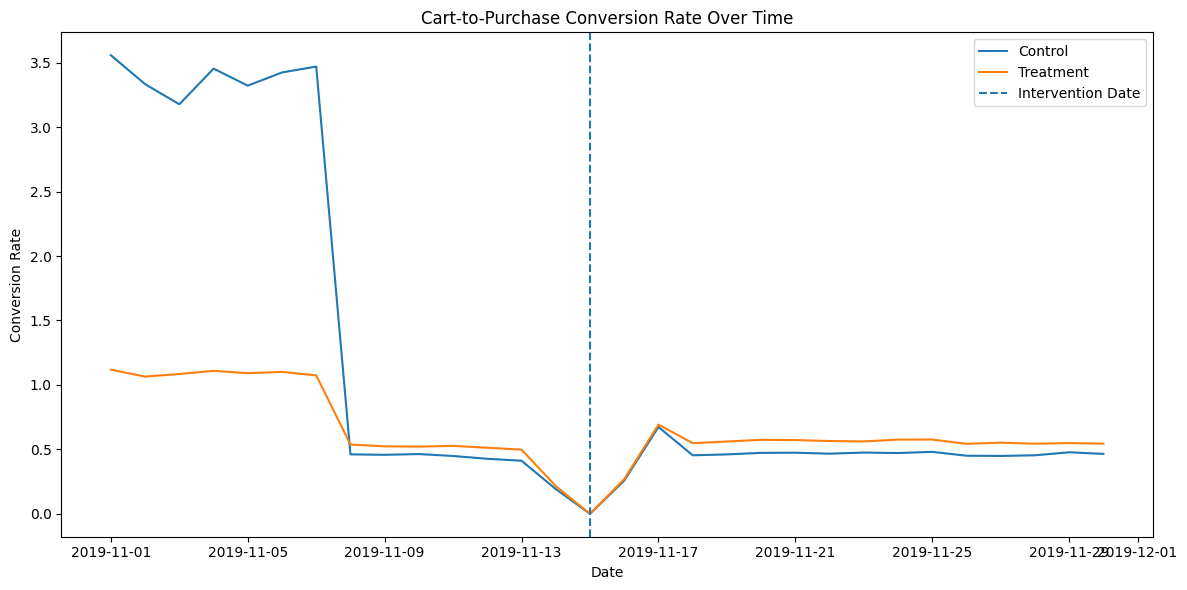



STEP 2: PRE-TREATMENT TREND CHECK
   is_treatment  cart_to_purchase_cr
0             0             1.900191
1             1             0.784127

NOTE:

This is a visual and descriptive check only.

For a portfolio project,
visual trend inspection is sufficient
to demonstrate understanding of the
parallel trends assumption.



STEP 3: DIFFERENCE-IN-DIFFERENCES
   is_treatment  is_post  cart_to_purchase_cr
0             0        0             1.900191
1             0        1             0.436370
2             1        0             0.784127
3             1        1             0.514127


DID RESULT
Control Pre      : 1.9002
Control Post     : 0.4364
Treatment Pre    : 0.7841
Treatment Post   : 0.5141

DID Effect       : 1.1938
DID Effect (%)   : 119.38%


EXECUTIVE SUMMARY

Estimated Impact:

119.38% increase

Interpretation:

After the intervention date,
the treatment category experienced
a relative 119.38%
increase in cart-to-purchase
conversion rate compared to
the control categor

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 80)
print("CAUSAL ANALYTICS - DIFFERENCE IN DIFFERENCES")
print("=" * 80)

# ==================================================
# LOAD DATA
# ==================================================

con = duckdb.connect(
    database="../data/warehouse/ecommerce.duckdb",
    read_only=True
)

df_did = con.execute("""
SELECT *
FROM mart_causal_did
""").df()

con.close()

print(f"\nRows Loaded: {len(df_did):,}")

if len(df_did) == 0:
    raise Exception("mart_causal_did is empty")

df_did["event_date"] = pd.to_datetime(
    df_did["event_date"]
)

print("\nSample Data:")
print(df_did.head())

# ==================================================
# STEP 1: VISUAL TREND ANALYSIS
# ==================================================

print("\n")
print("=" * 80)
print("STEP 1: VISUAL TREND ANALYSIS")
print("=" * 80)

plt.figure(figsize=(12, 6))

for treatment, label in [
    (0, "Control"),
    (1, "Treatment")
]:

    temp = (
        df_did[df_did["is_treatment"] == treatment]
        .groupby("event_date")["cart_to_purchase_cr"]
        .mean()
        .reset_index()
    )

    plt.plot(
        temp["event_date"],
        temp["cart_to_purchase_cr"],
        label=label
    )

plt.axvline(
    pd.to_datetime("2019-11-15"),
    linestyle="--",
    label="Intervention Date"
)

plt.title(
    "Cart-to-Purchase Conversion Rate Over Time"
)

plt.xlabel("Date")
plt.ylabel("Conversion Rate")

plt.legend()
plt.tight_layout()
plt.show()

# ==================================================
# STEP 2: PRE-TREATMENT TREND CHECK
# ==================================================

print("\n")
print("=" * 80)
print("STEP 2: PRE-TREATMENT TREND CHECK")
print("=" * 80)

df_pre = df_did[
    df_did["is_post"] == 0
]

pre_summary = (
    df_pre
    .groupby("is_treatment")
    ["cart_to_purchase_cr"]
    .mean()
    .reset_index()
)

print(pre_summary)

print("""
NOTE:

This is a visual and descriptive check only.

For a portfolio project,
visual trend inspection is sufficient
to demonstrate understanding of the
parallel trends assumption.
""")

# ==================================================
# STEP 3: DIFFERENCE-IN-DIFFERENCES
# ==================================================

print("\n")
print("=" * 80)
print("STEP 3: DIFFERENCE-IN-DIFFERENCES")
print("=" * 80)

summary = (
    df_did
    .groupby(
        ["is_treatment", "is_post"]
    )["cart_to_purchase_cr"]
    .mean()
    .reset_index()
)

print(summary)

control_pre = summary[
    (summary["is_treatment"] == 0)
    &
    (summary["is_post"] == 0)
]["cart_to_purchase_cr"].values

control_post = summary[
    (summary["is_treatment"] == 0)
    &
    (summary["is_post"] == 1)
]["cart_to_purchase_cr"].values

treatment_pre = summary[
    (summary["is_treatment"] == 1)
    &
    (summary["is_post"] == 0)
]["cart_to_purchase_cr"].values

treatment_post = summary[
    (summary["is_treatment"] == 1)
    &
    (summary["is_post"] == 1)
]["cart_to_purchase_cr"].values

if (
    len(control_pre) == 0
    or len(control_post) == 0
    or len(treatment_pre) == 0
    or len(treatment_post) == 0
):
    raise Exception(
        "Missing Treatment/Control observations"
    )

control_pre = control_pre[0]
control_post = control_post[0]

treatment_pre = treatment_pre[0]
treatment_post = treatment_post[0]

did_effect = (
    (treatment_post - treatment_pre)
    -
    (control_post - control_pre)
)

print("\n")
print("=" * 80)
print("DID RESULT")
print("=" * 80)

print(f"Control Pre      : {control_pre:.4f}")
print(f"Control Post     : {control_post:.4f}")

print(f"Treatment Pre    : {treatment_pre:.4f}")
print(f"Treatment Post   : {treatment_post:.4f}")

print(f"\nDID Effect       : {did_effect:.4f}")
print(f"DID Effect (%)   : {did_effect:.2%}")

# ==================================================
# STEP 4: EXECUTIVE SUMMARY
# ==================================================

print("\n")
print("=" * 80)
print("EXECUTIVE SUMMARY")
print("=" * 80)

direction = (
    "increase"
    if did_effect > 0
    else "decrease"
)

print(f"""
Estimated Impact:

{abs(did_effect):.2%} {direction}

Interpretation:

After the intervention date,
the treatment category experienced
a relative {abs(did_effect):.2%}
{direction} in cart-to-purchase
conversion rate compared to
the control category.

Business Implication:

Category-specific factors may have
influenced customer purchase behavior.

Recommendations:

1. Investigate checkout experience

2. Review pricing strategy

3. Analyze product assortment

4. Evaluate promotional campaigns

5. Validate findings through
   controlled experimentation
""")

print("\n")
print("=" * 80)
print("ANALYSIS COMPLETED")
print("=" * 80)

print("""
NOTE:

This Difference-in-Differences analysis
is intended for portfolio demonstration.

The intervention date is synthetic
and used to showcase causal analytics
methodology.

No real-world experiment exists
within the original dataset.
""")
